In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gaussian_jitter_smear import gaussian_jitter_smear

In [2]:
df1 = pd.read_csv(r'C:\Inverse ML\data\siimpl_rot\siimpl_train.csv')
df2 = pd.read_csv(r'C:\Inverse ML\data\siimpl_rot\siimpl_eval.csv')
df = pd.concat([df1, df2], ignore_index=True)

TARGETS = [10, 30, 100]
SIGMAS_NM = [0, 1, 6, 30]
TOL = 0.15

def project(pts, g):
    c = pts - pts.mean(0)
    proj = c @ g
    ref = np.array([1.0, 0.0, 0.0]) if abs(g[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    e1 = np.cross(ref, g); e1 /= np.linalg.norm(e1)
    lat = c @ e1
    return proj, lat

chosen = {}
for E in TARGETS:
    lo, hi = E*(1-TOL), E*(1+TOL)
    sub = df[(df.energy_keV >= lo) & (df.energy_keV < hi)]
    counts = sub.groupby('ion_number').size()
    med = counts.median()
    ion = (counts - med).abs().idxmin()
    rows = sub[sub.ion_number == ion]
    pts = rows[['x', 'y', 'z']].values  # Angstrom
    g = rows[['target_vx', 'target_vy', 'target_vz']].values[0]
    g = g / np.linalg.norm(g)
    chosen[E] = (pts, g)
    print(f'E={E} keV: chosen ion={ion}, n_vac={len(pts)}')

E=10 keV: chosen ion=118, n_vac=72


E=30 keV: chosen ion=263, n_vac=146


E=100 keV: chosen ion=5454, n_vac=244


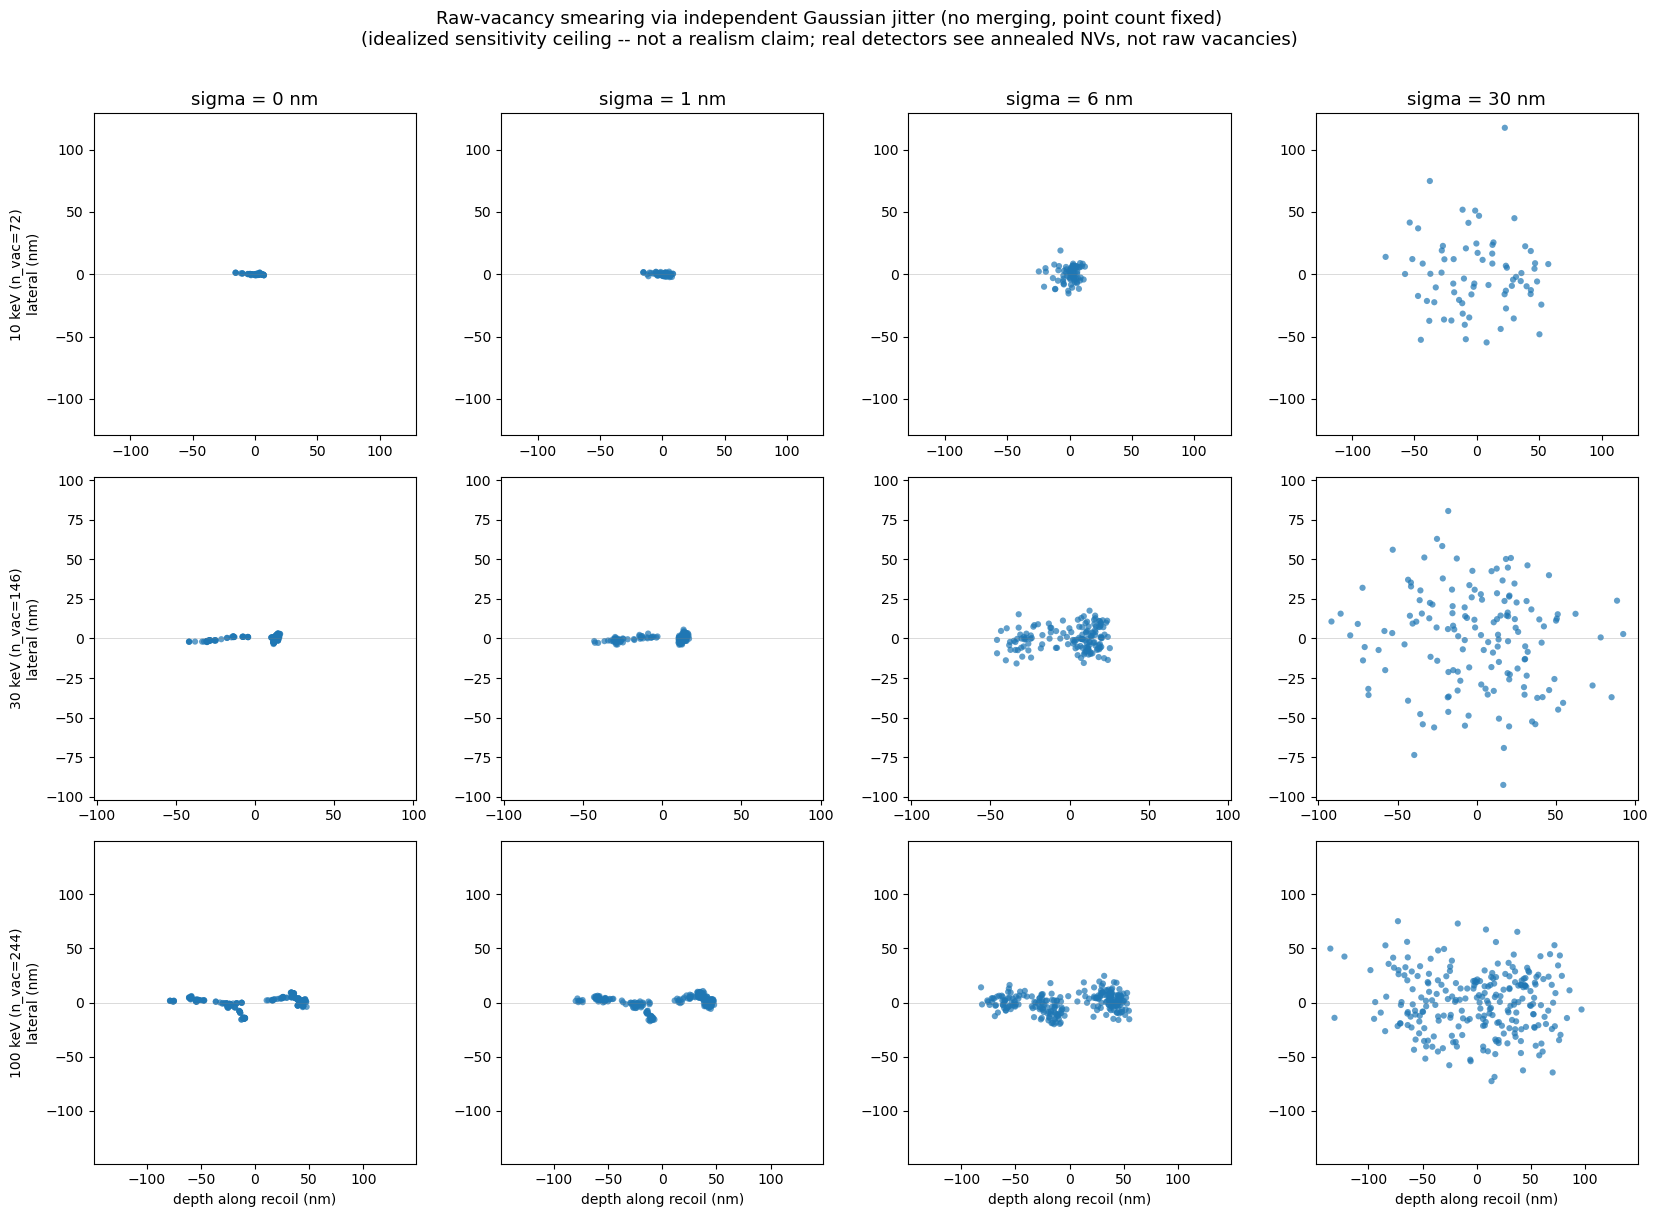

In [3]:
# simple independent-jitter smearing: each point gets random Gaussian noise
# added to its position, no merging -- point count stays the same, positions
# just get noisier as sigma grows
rng = np.random.default_rng(0)
n_rows = len(TARGETS)
fig, axes = plt.subplots(n_rows, len(SIGMAS_NM), figsize=(4.2*len(SIGMAS_NM), 4*n_rows))

for i, E in enumerate(TARGETS):
    pts_A, g = chosen[E]

    variants = {}
    for s_nm in SIGMAS_NM:
        sigma_A = s_nm * 10
        jittered = gaussian_jitter_smear(pts_A, sigma_A, rng=rng)
        variants[s_nm] = project(jittered / 10.0, g)
    max_extent = max(max(abs(proj).max(), abs(lat).max()) for proj, lat in variants.values())
    lim = max_extent * 1.1

    for c, s_nm in enumerate(SIGMAS_NM):
        proj, lat = variants[s_nm]
        ax = axes[i, c]
        ax.scatter(proj, lat, s=20, alpha=0.7, edgecolors='none')
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.axhline(0, color='gray', lw=0.5, alpha=0.4)
        ax.set_aspect('equal')
        if i == 0:
            ax.set_title(f'sigma = {s_nm} nm', fontsize=13)
        ylabel = f'{E} keV (n_vac={len(pts_A)})\nlateral (nm)' if c == 0 else ''
        ax.set_ylabel(ylabel, fontsize=10)
        if i == n_rows - 1:
            ax.set_xlabel('depth along recoil (nm)')

title = ('Raw-vacancy smearing via independent Gaussian jitter (no merging, point count fixed)\n'
         '(idealized sensitivity ceiling -- not a realism claim; real detectors see annealed NVs, not raw vacancies)')
fig.suptitle(title, fontsize=13, y=1.01)
fig.tight_layout()